In [ ]:
!pip install requests beautifulsoup4 textblob nltk matplotlib wordcloud gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.9 MB/s eta 0:00:00


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk, re
from nltk.corpus import stopwords
from gensim import corpora, models
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def get_reviews(imdb_url, num_pages=7):
    reviews = []
    headers = {'User-Agent': 'Mozilla/5.0'}
    for i in range(0, num_pages*10, 10):
        url = f"{imdb_url}?start={i}&ref_=tt_urv"
        r = requests.get(url, headers=headers)
        soup = BeautifulSoup(r.text, 'html.parser')
        for div in soup.find_all("div", class_="ipc-html-content"):
            text = div.get_text(strip=True)
            if len(text.split()) > 5:  # avoid too-short elements
                reviews.append(text)
    return reviews


🎬 Analyzing Movie: Pathaan (2023)

🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)
🔹 Average Sentiment Score: 0.513
(+1 = positive, -1 = negative, 0 = neutral)



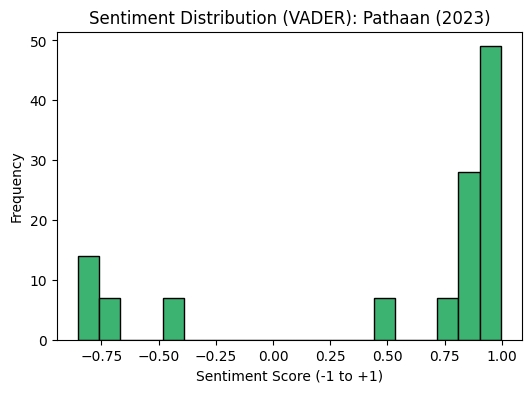


--- Top Topics (LDA) ---
Topic 1: 0.043*"movie" + 0.015*"action" + 0.011*"story" + 0.011*"tiger" + 0.009*"john" + 0.007*"khan"
Topic 2: 0.027*"film" + 0.021*"movie" + 0.013*"like" + 0.013*"good" + 0.010*"srk" + 0.010*"story"
Topic 3: 0.035*"movie" + 0.022*"srk" + 0.021*"action" + 0.012*"movies" + 0.012*"good" + 0.011*"film"


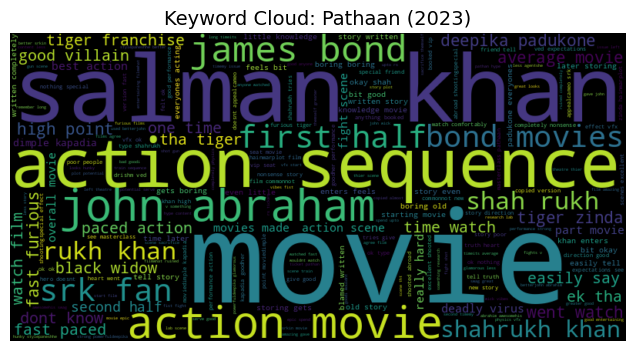

In [ ]:
movie_title = "Pathaan (2023)"
imdb_link = "https://www.imdb.com/title/tt12844910/reviews/"
print(f"\n===============================")
print(f"🎬 Analyzing Movie: {movie_title}")
print(f"===============================\n")

reviews = get_reviews(imdb_link)
if len(reviews) == 0:
    print("⚠️ No reviews collected. IMDb may have updated layout or restricted scraping.")
else:
    stop_words = set(stopwords.words('english'))
    cleaned = []
    for r in reviews:
        text = re.sub(r'[^a-zA-Z ]', '', r.lower())  # Remove punctuation/numbers
        words = [w for w in text.split() if w not in stop_words]
        cleaned.append(' '.join(words))
    # Step 3: Sentiment Analysis (VADER-Lexicon-based)
    sia = SentimentIntensityAnalyzer()
    scores = [sia.polarity_scores(r)['compound'] for r in cleaned]
    avg_sentiment = sum(scores) / len(scores) if scores else 0
    print(f"🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)")
    print(f"🔹 Average Sentiment Score: {avg_sentiment:.3f}")
    print("(+1 = positive, -1 = negative, 0 = neutral)\n")

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=20, color='mediumseagreen', edgecolor='black')
    plt.title(f"Sentiment Distribution (VADER): {movie_title}")
    plt.xlabel("Sentiment Score (-1 to +1)")
    plt.ylabel("Frequency")
    plt.show()

   # Step 4: Topic Modeling
    tokens = [r.split() for r in cleaned]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(text) for text in tokens]
    lda_model = models.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

    print("\n--- Top Topics (LDA) ---")
    for idx, topic in lda_model.print_topics(num_words=6):
        print(f"Topic {idx+1}: {topic}")

    # Step 5: Word Cloud Visualization
    text_combined = ' '.join(cleaned)
    wc = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Keyword Cloud: {movie_title}", fontsize=14)
    plt.axis('off')
    plt.show()


🎬 Analyzing Movie: Bade Miyan Chote Miyan (2024)

🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)
🔹 Average Sentiment Score: -0.048
(+1 = positive, -1 = negative, 0 = neutral)



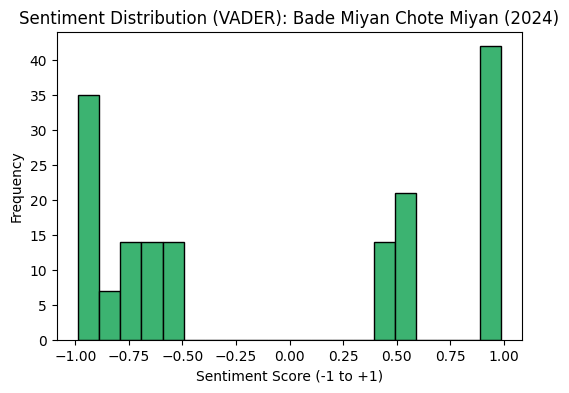


--- Top Topics (LDA) ---
Topic 1: 0.024*"movie" + 0.024*"bad" + 0.016*"akshay" + 0.011*"tiger" + 0.011*"one" + 0.010*"acting"
Topic 2: 0.037*"movie" + 0.014*"action" + 0.014*"film" + 0.012*"one" + 0.010*"akshay" + 0.010*"movies"
Topic 3: 0.024*"movie" + 0.019*"action" + 0.013*"like" + 0.009*"even" + 0.009*"felt" + 0.009*"good"


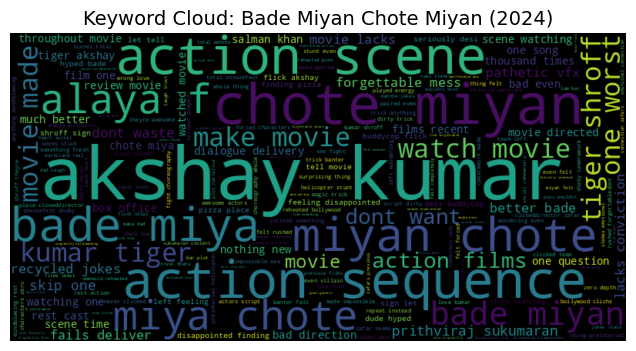

In [ ]:
movie_title = "Bade Miyan Chote Miyan (2024)"
imdb_link = "https://www.imdb.com/title/tt18072316/reviews/"
print(f"\n===============================")
print(f"🎬 Analyzing Movie: {movie_title}")
print(f"===============================\n")

reviews = get_reviews(imdb_link)
if len(reviews) == 0:
    print("⚠️ No reviews collected. IMDb may have updated layout or restricted scraping.")
else:
    stop_words = set(stopwords.words('english'))
    cleaned = []
    for r in reviews:
        text = re.sub(r'[^a-zA-Z ]', '', r.lower())  # Remove punctuation/numbers
        words = [w for w in text.split() if w not in stop_words]
        cleaned.append(' '.join(words))
    # Step 3: Sentiment Analysis (VADER-Lexicon-based)
    sia = SentimentIntensityAnalyzer()
    scores = [sia.polarity_scores(r)['compound'] for r in cleaned]
    avg_sentiment = sum(scores) / len(scores) if scores else 0
    print(f"🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)")
    print(f"🔹 Average Sentiment Score: {avg_sentiment:.3f}")
    print("(+1 = positive, -1 = negative, 0 = neutral)\n")

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=20, color='mediumseagreen', edgecolor='black')
    plt.title(f"Sentiment Distribution (VADER): {movie_title}")
    plt.xlabel("Sentiment Score (-1 to +1)")
    plt.ylabel("Frequency")
    plt.show()

   # Step 4: Topic Modeling
    tokens = [r.split() for r in cleaned]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(text) for text in tokens]
    lda_model = models.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

    print("\n--- Top Topics (LDA) ---")
    for idx, topic in lda_model.print_topics(num_words=6):
        print(f"Topic {idx+1}: {topic}")

    # Step 5: Word Cloud Visualization
    text_combined = ' '.join(cleaned)
    wc = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Keyword Cloud: {movie_title}", fontsize=14)
    plt.axis('off')
    plt.show()


🎬 Analyzing Movie: Don 2 (2011)

🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)
🔹 Average Sentiment Score: 0.851
(+1 = positive, -1 = negative, 0 = neutral)



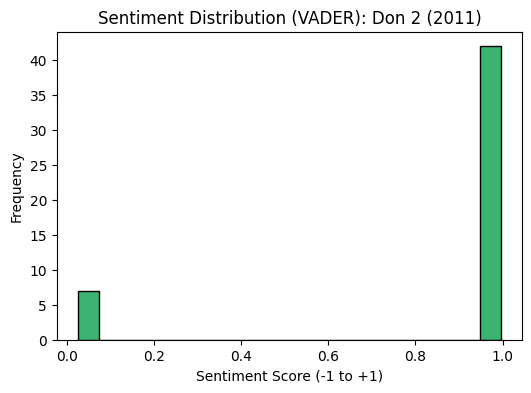


--- Top Topics (LDA) ---
Topic 1: 0.026*"movie" + 0.012*"film" + 0.010*"acting" + 0.010*"storyline" + 0.010*"srk" + 0.007*"first"
Topic 2: 0.016*"khan" + 0.016*"shah" + 0.016*"rukh" + 0.012*"film" + 0.012*"priyanka" + 0.012*"every"
Topic 3: 0.025*"film" + 0.017*"sequel" + 0.017*"action" + 0.012*"first" + 0.012*"n" + 0.012*"films"


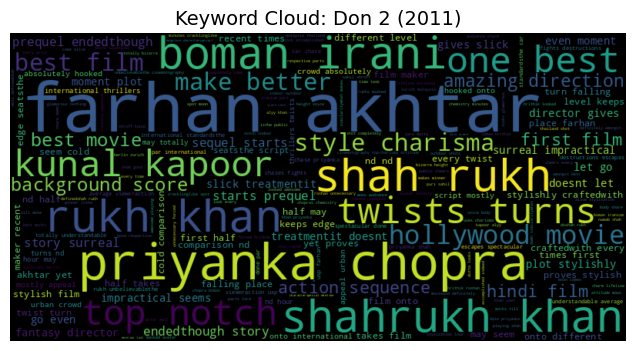

In [ ]:
movie_title = "Don 2 (2011)"
imdb_link = "https://www.imdb.com/title/tt1285241/reviews/"
print(f"\n===============================")
print(f"🎬 Analyzing Movie: {movie_title}")
print(f"===============================\n")

reviews = get_reviews(imdb_link)
if len(reviews) == 0:
    print("⚠️ No reviews collected. IMDb may have updated layout or restricted scraping.")
else:
    stop_words = set(stopwords.words('english'))
    cleaned = []
    for r in reviews:
        text = re.sub(r'[^a-zA-Z ]', '', r.lower())  # Remove punctuation/numbers
        words = [w for w in text.split() if w not in stop_words]
        cleaned.append(' '.join(words))
    # Step 3: Sentiment Analysis (VADER-Lexicon-based)
    sia = SentimentIntensityAnalyzer()
    scores = [sia.polarity_scores(r)['compound'] for r in cleaned]
    avg_sentiment = sum(scores) / len(scores) if scores else 0
    print(f"🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)")
    print(f"🔹 Average Sentiment Score: {avg_sentiment:.3f}")
    print("(+1 = positive, -1 = negative, 0 = neutral)\n")

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=20, color='mediumseagreen', edgecolor='black')
    plt.title(f"Sentiment Distribution (VADER): {movie_title}")
    plt.xlabel("Sentiment Score (-1 to +1)")
    plt.ylabel("Frequency")
    plt.show()

   # Step 4: Topic Modeling
    tokens = [r.split() for r in cleaned]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(text) for text in tokens]
    lda_model = models.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

    print("\n--- Top Topics (LDA) ---")
    for idx, topic in lda_model.print_topics(num_words=6):
        print(f"Topic {idx+1}: {topic}")

    # Step 5: Word Cloud Visualization
    text_combined = ' '.join(cleaned)
    wc = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Keyword Cloud: {movie_title}", fontsize=14)
    plt.axis('off')
    plt.show()


🎬 Analyzing Movie: Holiday (2014)

🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)
🔹 Average Sentiment Score: 0.614
(+1 = positive, -1 = negative, 0 = neutral)



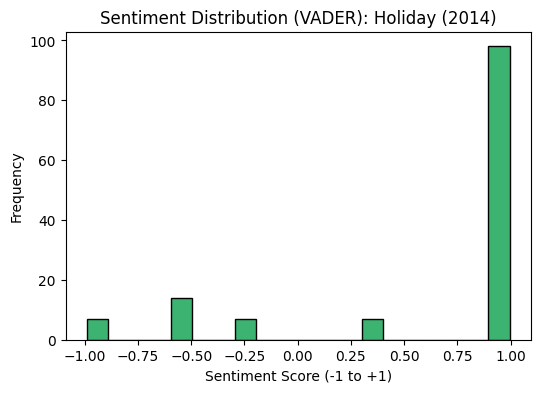


--- Top Topics (LDA) ---
Topic 1: 0.018*"akshay" + 0.015*"movie" + 0.013*"kumar" + 0.010*"virat" + 0.010*"sonakshi" + 0.009*"never"
Topic 2: 0.020*"akshay" + 0.017*"holiday" + 0.013*"movie" + 0.013*"good" + 0.013*"film" + 0.011*"sonakshi"
Topic 3: 0.021*"holiday" + 0.021*"akshay" + 0.017*"movie" + 0.013*"kumar" + 0.010*"action" + 0.010*"army"


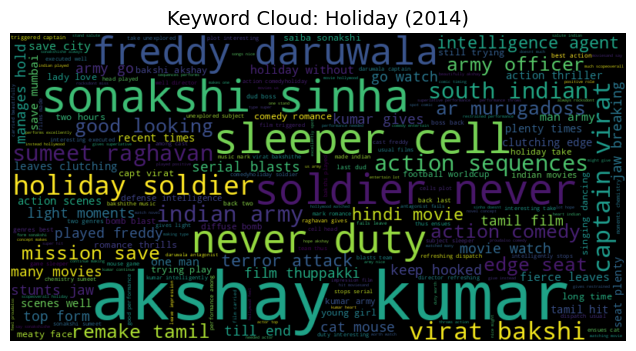

In [ ]:
movie_title = "Holiday (2014)"
imdb_link = "https://www.imdb.com/title/tt2556308/reviews/"
print(f"\n===============================")
print(f"🎬 Analyzing Movie: {movie_title}")
print(f"===============================\n")

reviews = get_reviews(imdb_link)
if len(reviews) == 0:
    print("⚠️ No reviews collected. IMDb may have updated layout or restricted scraping.")
else:
    stop_words = set(stopwords.words('english'))
    cleaned = []
    for r in reviews:
        text = re.sub(r'[^a-zA-Z ]', '', r.lower())  # Remove punctuation/numbers
        words = [w for w in text.split() if w not in stop_words]
        cleaned.append(' '.join(words))
    # Step 3: Sentiment Analysis (VADER-Lexicon-based)
    sia = SentimentIntensityAnalyzer()
    scores = [sia.polarity_scores(r)['compound'] for r in cleaned]
    avg_sentiment = sum(scores) / len(scores) if scores else 0
    print(f"🔹 Sentiment Analysis Method: VADER (Lexicon-based, context-aware)")
    print(f"🔹 Average Sentiment Score: {avg_sentiment:.3f}")
    print("(+1 = positive, -1 = negative, 0 = neutral)\n")

    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=20, color='mediumseagreen', edgecolor='black')
    plt.title(f"Sentiment Distribution (VADER): {movie_title}")
    plt.xlabel("Sentiment Score (-1 to +1)")
    plt.ylabel("Frequency")
    plt.show()

   # Step 4: Topic Modeling
    tokens = [r.split() for r in cleaned]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(text) for text in tokens]
    lda_model = models.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

    print("\n--- Top Topics (LDA) ---")
    for idx, topic in lda_model.print_topics(num_words=6):
        print(f"Topic {idx+1}: {topic}")

    # Step 5: Word Cloud Visualization
    text_combined = ' '.join(cleaned)
    wc = WordCloud(width=800, height=400, background_color='black').generate(text_combined)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Keyword Cloud: {movie_title}", fontsize=14)
    plt.axis('off')
    plt.show()